In [117]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import sys, os; sys.path.append(os.path.abspath('..'))
from database.db_config import get_engine
from scipy.stats import shapiro #for shapiro test 
from scipy.stats import mannwhitneyu # for mann whitley test
from matplotlib.ticker import FuncFormatter

In [118]:
engine = get_engine()

## Query for salary distribution analysis

In [119]:
query = ("SELECT salary_avg_pln, country, category, is_estimated, company_name FROM offers WHERE salary_avg_pln > 30000 AND category = 'IT'") 

In [120]:
df = pd.read_sql(query,engine)

## Global Salary Distribution (KDE + Histogram)


## Chart

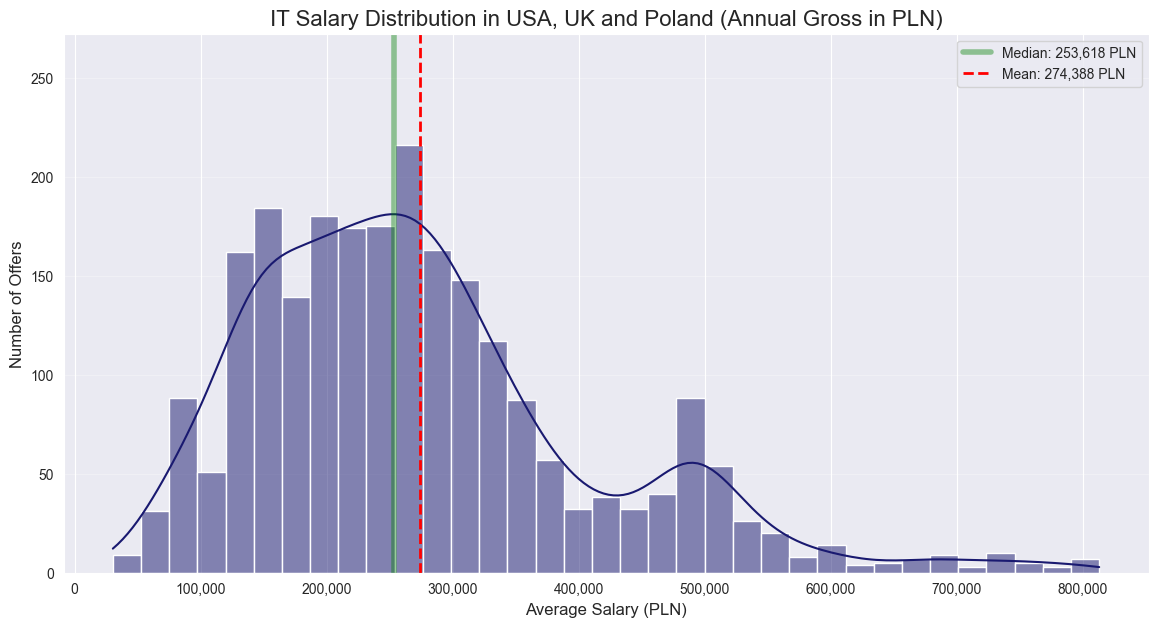

In [121]:
# Filtering the outliers (quantile 0.99) 
upper_limit = df['salary_avg_pln'].quantile(0.99)
df_filtered = df[df['salary_avg_pln'] <= upper_limit]


mean_val = df_filtered["salary_avg_pln"].mean()
median_val = df_filtered["salary_avg_pln"].median()

plt.figure(figsize=(14, 7))

#histogram
ax = sns.histplot(data=df_filtered, x='salary_avg_pln', kde=True, color='midnightblue', bins=35, alpha=0.5, edgecolor='white',linewidth=1)

# y axis scaling
current_ylim = plt.gca().get_ylim()
plt.ylim(0, current_ylim[1] * 1.2) 

#stat lines
plt.axvline(median_val, color='green', linestyle='-', linewidth=4, alpha=0.4, label=f'Median: {median_val:,.0f} PLN')
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:,.0f} PLN')

# x axis formatting
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title('IT Salary Distribution in USA, UK and Poland (Annual Gross in PLN)', fontsize=16)
plt.xlabel('Average Salary (PLN)', fontsize=12)
plt.ylabel('Number of Offers', fontsize=12)

plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3) 


## Key Insights: The distribution is heavily right-skewed with a tail extending to 800k PLN. The median 253k PLN represents the standard role globally, the mean is inflated by high US offers. 
## Almost all offers probably originate from the US market and nearly 50% of polish offers are not listed with salary, hence the chart is not a really good representation. 

# Checking how many offers are above 600k PLN annually (85)

In [122]:
df[(df["salary_avg_pln"] > 600000)]["country"].count()

np.int64(85)

# Checking how many of them are from US (63)

In [123]:
df[(df["country"] == "us") & (df["salary_avg_pln"] > 600000)]["country"].count()


np.int64(63)

Rynek polski

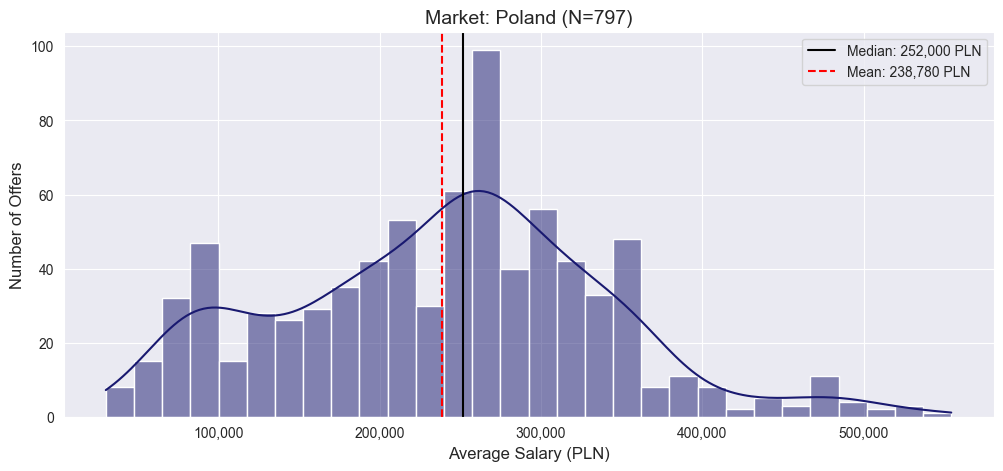

In [124]:
plt.figure(figsize=(12, 5))
data_pl = df[df['country'] == 'pl']
upper_pl = data_pl['salary_avg_pln'].quantile(0.99)
filtered_pl = data_pl[data_pl['salary_avg_pln'] <= upper_pl]

sns.histplot(data=filtered_pl, x='salary_avg_pln', kde=True, color='midnightblue', bins=30, alpha=0.5)

med_pl = filtered_pl['salary_avg_pln'].median()
mean_pl = filtered_pl['salary_avg_pln'].mean()
plt.axvline(med_pl, color='black', label=f'Median: {med_pl:,.0f} PLN')
plt.axvline(mean_pl, color='red', linestyle='--', label=f'Mean: {mean_pl:,.0f} PLN')

plt.title(f"Market: Poland (N={len(filtered_pl)})", fontsize=14)
plt.xlabel('Average Salary (PLN)', fontsize=12)
plt.ylabel('Number of Offers', fontsize=12)
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))
plt.legend()
plt.show()

## The high median 252k is likely inflated by a lack of transparency in the broader market. In Poland, salary brackets are most commonly disclosed for mid and senior b2b roles while many junior and lower-paid permanent positions remain hidden. The distribution shows two peaks: first one around 100k represents entry-level roles while the dominant 250k-300k area reflects senior/b2b contracts reality that defines the polish IT market. 

# Transparency representation on pie chart

Text(0.5, 1.0, 'Salary Transparency in Polish IT Offers')

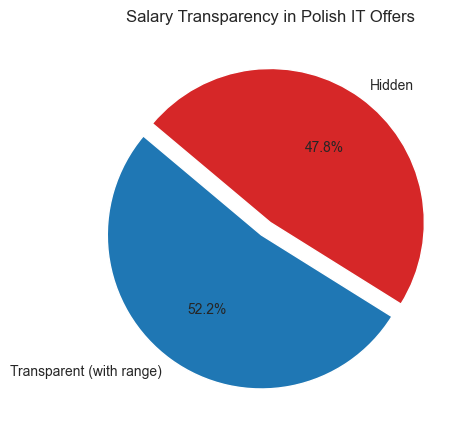

In [125]:
pl_stats = {'Transparent (with range)': 928, 'Hidden': 849}

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

plt.pie(pl_stats.values(), labels=pl_stats.keys(), autopct='%1.1f%%', 
        colors=['tab:blue', 'tab:red'], explode=(0.1, 0), startangle=140)

plt.title("Salary Transparency in Polish IT Offers")

## GB

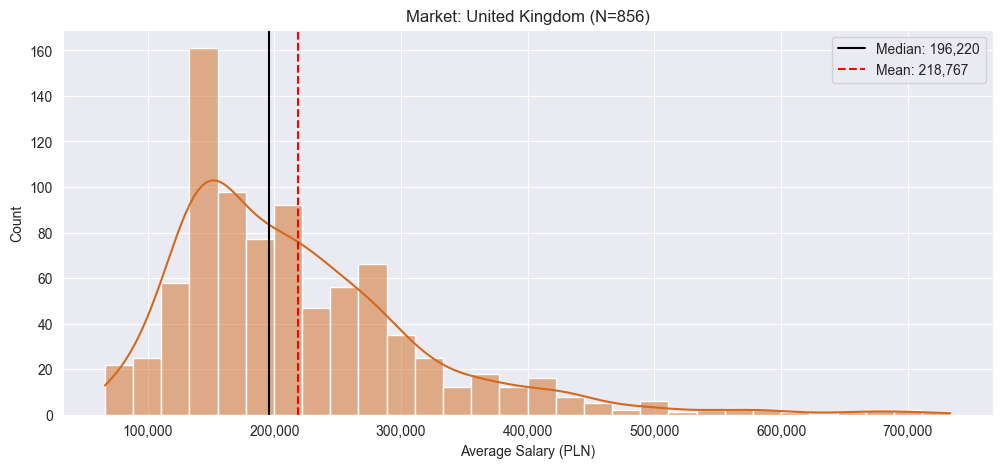

In [126]:
s = df[df['country'] == 'gb']['salary_avg_pln']
s = s[s <= s.quantile(0.99)]

plt.figure(figsize=(12, 5))
sns.histplot(s, kde=True, color='chocolate', bins=30, alpha=0.5)

plt.axvline(s.median(), color='black', label=f"Median: {s.median():,.0f}")
plt.axvline(s.mean(), color='red', ls='--', label=f"Mean: {s.mean():,.0f}")

plt.title(f"Market: United Kingdom (N={len(s)})")
plt.xlabel("Average Salary (PLN)")
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend()

## The UK distribution is more compact than in US with a strong concentration in the 150k - 250k range. It indicates an established salary standards for most IT jobs. It indicates smoother KDE curve compared to Poland. The median appears lower than in Poland likely because UK market is considerably more transparent.  

## US

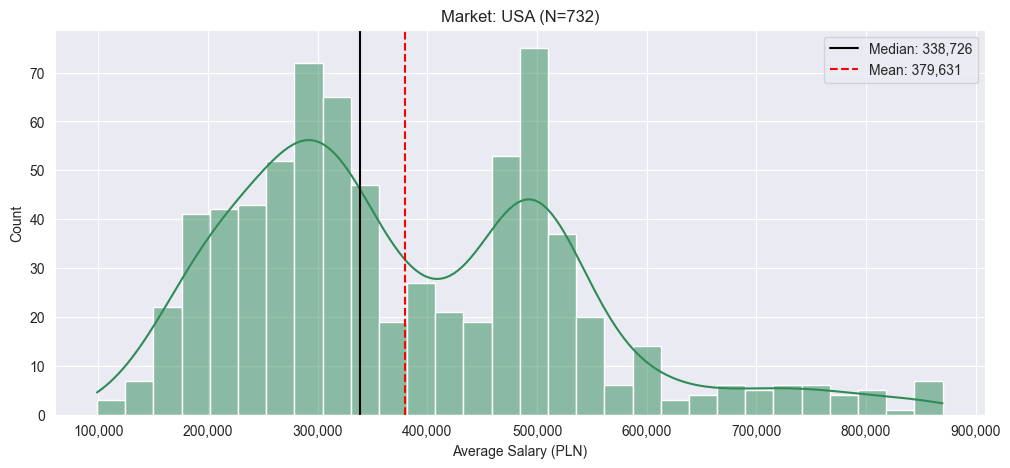

In [127]:
s = df[df['country'] == 'us']['salary_avg_pln']
s = s[s <= s.quantile(0.99)]

plt.figure(figsize=(12, 5))
sns.histplot(s, kde=True, color='seagreen', bins=30, alpha=0.5)

# 3. Linie statystyk
plt.axvline(s.median(), color='black', label=f"Median: {s.median():,.0f}")
plt.axvline(s.mean(), color='red', ls='--', label=f"Mean: {s.mean():,.0f}")

plt.title(f"Market: USA (N={len(s)})")
plt.xlabel("Average Salary (PLN)")
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend()
plt.show()

## At first glance the US market operates on a completely different financial level. The distributoin is highly right-skewed with a significant long tail amounting to 900k. Unlike the European markets it shows two clusters of high activity: around 300k PLN and 500k PLN the latter could be specialized roles in AI, Big tech (FANG). 

## Let's check if the most paid companies are from FANG and AI 

In [128]:
high_earners_it = pd.read_sql("SELECT company_name, salary_avg_pln FROM offers WHERE country = 'us' AND category = 'IT' AND salary_avg_pln > 800000", engine)


In [129]:
high_earners_it.value_counts().head(50)

company_name                          salary_avg_pln
Circle                                8.370243e+05      1
CommonSpirit Health                   8.701849e+05      1
Colony Capital                        8.696407e+05      1
STS Technical Services                8.566842e+05      1
Judge Group, Inc.                     1.541538e+06      1
HighLevel                             8.042946e+05      1
                                      8.084041e+05      1
                                      8.672124e+05      1
                                      8.573912e+05      1
                                      8.131990e+05      1
                                      9.178494e+05      1
                                      8.727647e+05      1
Cellectis                             8.449692e+05      1
Robert Half                           9.735641e+05      1
Judge Group, Inc.                     2.099172e+06      1
Document Storage Systems Inc          8.458577e+05      1
Electronic Consulti

## As you can see the highest salaries in our dataset aren't driven by big tech. Instead they're dominated by healthcare (commonspirit health) and investment sectors (real estate investment). Most of these roles are executive level contracts and niche consulting roles than standard engineering positions. 

## Let's check if UK and US have normal distribution 

In [130]:
usa_salaries = df[df['country'] == 'us']['salary_avg_pln'].dropna()
uk_salaries = df[df['country'] == 'gb']['salary_avg_pln'].dropna()
stat_us, p_value_us = shapiro(usa_salaries)
stat_uk, p_value_uk = shapiro(uk_salaries)


In [131]:
print(f"{p_value_us:.50f}")

0.00000000000000000000000060800845798353590685891341


In [132]:
print(f"{p_value_uk:.50f}")

0.00000000000000000000000000000024749651102315122365


## Since the Shapiro-Wilk test confirmed that the salary distributoins are not normal, a standard T test isn't appropriate. Instead we use the Mann-Whitney Test. It's a method to determine if one group's salaries are significantly higher than the other's

In [133]:

stat, p_mu = mannwhitneyu(usa_salaries, uk_salaries)
print(f"p-value: {p_mu}")

p-value: 1.0701574620113032e-111


### p_value < 0.001.

## The test yielded an extremely low p-value which is far below 0.05. Hence we reject the null hypothesis that the salary distributions are identical. Based on the median values and previous testing the US market outperforms the UK market considerably